In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score, davies_bouldin_score
from joblib import dump, load
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

df_scaled = pickle.load(open('data/df_scaled.pkl', 'rb'))
df_clean  = pickle.load(open('data/df_clean.pkl',  'rb'))
df_pca    = pickle.load(open('data/df_pca.pkl',    'rb'))
scaler    = pickle.load(open('data/scaler.pkl',    'rb'))
features  = pickle.load(open('data/features.pkl',  'rb'))

print('Data loaded. Shape:', df_scaled.shape)


Data loaded. Shape: (2224, 9)


In [2]:
print('Testing quantile values for bandwidth...')
for q in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]:
    bw       = estimate_bandwidth(df_scaled, quantile=q)
    ms_test  = MeanShift(bandwidth=bw)
    lbl_test = ms_test.fit_predict(df_scaled)
    n        = len(set(lbl_test))
    print(f'  quantile={q}  bandwidth={bw:.4f}  clusters={n}')
print('\nChoose quantile that gives 3-6 clusters.')


Testing quantile values for bandwidth...
  quantile=0.05  bandwidth=2.2582  clusters=22
  quantile=0.1  bandwidth=2.6062  clusters=10
  quantile=0.15  bandwidth=2.8546  clusters=7
  quantile=0.2  bandwidth=3.0581  clusters=4
  quantile=0.25  bandwidth=3.2392  clusters=4
  quantile=0.3  bandwidth=3.4039  clusters=4

Choose quantile that gives 3-6 clusters.


In [3]:
QUANTILE  = 0.2   # adjust based on output above
bandwidth = estimate_bandwidth(df_scaled, quantile=QUANTILE)
print(f'Using bandwidth={bandwidth:.4f}  (quantile={QUANTILE})')

print('Training MeanShift...')
ms        = MeanShift(bandwidth=bandwidth)
ms_labels = ms.fit_predict(df_scaled)

n_clusters = len(set(ms_labels))
print(f'Clusters found: {n_clusters}')
unique, counts = np.unique(ms_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} customers')


Using bandwidth=3.0581  (quantile=0.2)
Training MeanShift...
Clusters found: 4
  Cluster 0: 2208 customers
  Cluster 1: 8 customers
  Cluster 2: 7 customers
  Cluster 3: 1 customers


In [4]:
sil = silhouette_score(df_scaled, ms_labels) if n_clusters >= 2 else -1
dbs = davies_bouldin_score(df_scaled, ms_labels) if n_clusters >= 2 else -1

print('=== MeanShift Evaluation Metrics ===')
print(f'Bandwidth           : {bandwidth:.4f}')
print(f'Clusters found      : {n_clusters}')
print(f'Silhouette Score    : {sil:.4f}  (higher = better)')
print(f'Davies-Bouldin Score: {dbs:.4f}  (lower  = better)')

scores = {'algorithm': 'MeanShift', 'n_clusters': n_clusters,
          'silhouette': round(sil, 4), 'davies_bouldin': round(dbs, 4),
          'inertia': 'N/A', 'noise': 0}
pickle.dump(scores,    open('data/meanshift_scores.pkl', 'wb'))
pickle.dump(ms_labels, open('data/meanshift_labels.pkl', 'wb'))


=== MeanShift Evaluation Metrics ===
Bandwidth           : 3.0581
Clusters found      : 4
Silhouette Score    : 0.1025  (higher = better)
Davies-Bouldin Score: 1.0943  (lower  = better)


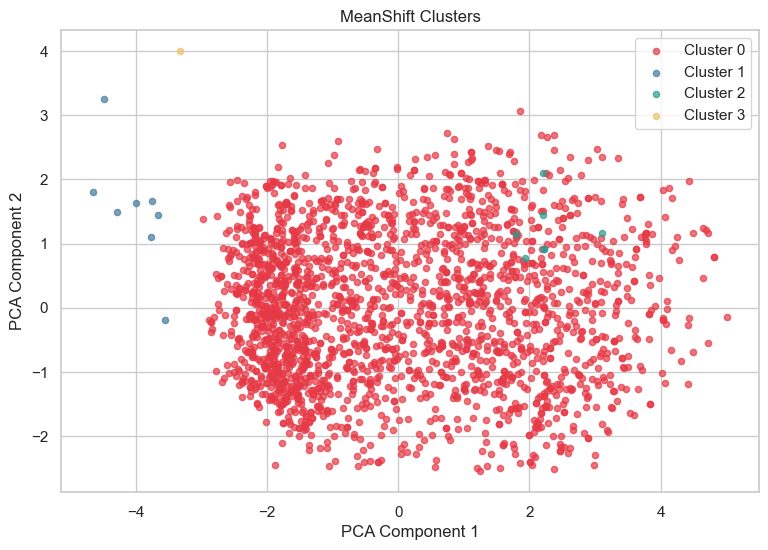

In [5]:
colors = ['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261','#264653','#7B2D8B']

plt.figure(figsize=(9, 6))
for i in range(n_clusters):
    mask = ms_labels == i
    plt.scatter(df_pca[mask, 0], df_pca[mask, 1],
                s=20, color=colors[i % len(colors)],
                label=f'Cluster {i}', alpha=0.7)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('MeanShift Clusters')
plt.legend()
plt.savefig('data/meanshift_pca.png', dpi=150, bbox_inches='tight')
plt.show()


=== Cluster Profiles (Mean Values) ===
           Age    Income  TotalSpend  TotalPurchases  TotalChildren  Recency  \
Cluster                                                                        
0        55.16  51714.84      600.34           14.83           0.96    49.15   
1        56.88   4808.00       77.38            4.50           0.88    41.00   
2        48.43  59030.29     1557.43           33.14           0.57    42.86   
3        33.00   8028.00      178.00           16.00           0.00    62.00   

         Days_Customer  TotalAccepted  NumWebVisitsMonth  
Cluster                                                   
0              3826.64           0.45               5.29  
1              3686.25           0.12              17.12  
2              4048.43           0.00               3.86  
3              4122.00           0.00              19.00  


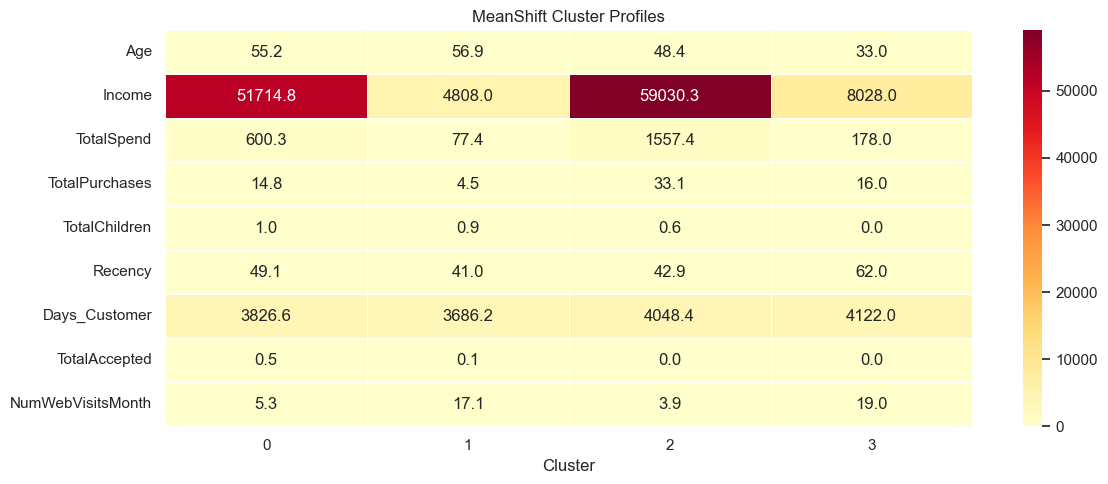

In [6]:
# Cluster profiles
df_result            = df_clean.copy()
df_result['Cluster'] = ms_labels
profile              = df_result.groupby('Cluster').mean().round(2)

print('=== Cluster Profiles (Mean Values) ===')
print(profile)

plt.figure(figsize=(12, 5))
sns.heatmap(profile.T, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('MeanShift Cluster Profiles')
plt.tight_layout()
plt.savefig('data/meanshift_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
from joblib import dump

dump(ms, 'data/meanshift_model.joblib')
print('Model saved: data/meanshift_model.joblib')
print(f'  Bandwidth : {bandwidth:.4f}')
print(f'  Clusters  : {n_clusters}')


Model saved: data/meanshift_model.joblib
  Bandwidth : 3.0581
  Clusters  : 4


In [8]:
from joblib import load

model = load('data/meanshift_model.joblib')

# Update these after seeing your actual cluster profiles!
cluster_labels = {
    0: 'High Income, High Spender (VIP)',
    1: 'Low Income, Low Spender (Budget)',
    2: 'Medium Income, Regular Buyer',
}

print('Model loaded successfully!')
print('Ready to predict new customer cluster.')


Model loaded successfully!
Ready to predict new customer cluster.


In [9]:
print('=== Enter New Customer Details ===')

age             = float(input('Enter Age: '))
income          = float(input('Enter Annual Income: '))
total_spend     = float(input('Enter Total Spend: '))
total_purchases = float(input('Enter Total Purchases: '))
total_children  = float(input('Enter Total Children: '))
recency         = float(input('Enter Recency (days since last purchase): '))
days_customer   = float(input('Enter Days as Customer: '))
total_accepted  = float(input('Enter Total Campaigns Accepted (0-6): '))
web_visits      = float(input('Enter Web Visits per Month: '))

new_customer        = np.array([[age, income, total_spend, total_purchases,
                                  total_children, recency, days_customer,
                                  total_accepted, web_visits]])
new_customer_scaled = scaler.transform(new_customer)

# MeanShift supports .predict() natively
predicted_cluster = model.predict(new_customer_scaled)[0]

print(f'\n=== Prediction Result ===')
print(f'Customer belongs to : Cluster {predicted_cluster}')
print(f'Cluster Description : {cluster_labels.get(predicted_cluster, "Unknown")}')


=== Enter New Customer Details ===


Enter Age:  18
Enter Annual Income:  36000
Enter Total Spend:  1000
Enter Total Purchases:  5
Enter Total Children:  0
Enter Recency (days since last purchase):  365
Enter Days as Customer:  2
Enter Total Campaigns Accepted (0-6):  5
Enter Web Visits per Month:  5



=== Prediction Result ===
Customer belongs to : Cluster 0
Cluster Description : High Income, High Spender (VIP)
